In [8]:
import ler
import numpy as np
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json, param_plot, relative_mu_dt_unlensed, mu_vs_dt_plot
from ler.rates import LeR
import json

In [3]:
ler.__version__

'0.4.2'

In [5]:
ler = LeR(
    npool=6,
    event_type="BBH",
    ifos = ['L1', 'H1'],
    psds={'L1':'T2500310-v2_O5a_strain_psd.txt',
          'H1':'T2500310-v2_O5a_strain_psd.txt'},
    waveform_approximant="IMRPhenomXPHM",
    spin_zero=False, 
    spin_precession=True,
    verbose=False,
    )


interpolation for each mass_ratios: 100%|███████████████████████████| 50/50 [01:14<00:00,  1.49s/it]


In [6]:
lensed_params = ler.selecting_n_lensed_detectable_events(
    size=500,
    batch_size=20000,
    snr_threshold=10,
    num_img=2, # minimum 2 images will have SNR>=10
    resume=False, 
    output_jsonfile="n_lensed_params_bbh.txt",
    meta_data_file="meta_data_lensed_bbh.json",
)


removing ./ler_data/n_lensed_params_bbh.txt and ./ler_data/meta_data_lensed_bbh.json if they exist
collected number of detectable events =  0


100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.04it/s]


given detectability_condition == step_function
collected number of detectable events =  50
total number of events =  20000
total rate (yr^-1): 0.5677279948779829


100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.99it/s]


given detectability_condition == step_function
collected number of detectable events =  125
total number of events =  40000
total rate (yr^-1): 0.7096599935974784


...

given detectability_condition == step_function
collected number of detectable events =  392
total number of events =  120000
total rate (yr^-1): 0.7418312466405642


100%|███████████████████████████████████████████████████████| 20000/20000 [00:11<00:00, 1804.80it/s]


given detectability_condition == step_function
collected number of detectable events =  452
total number of events =  140000
total rate (yr^-1): 0.7331801533852806


100%|███████████████████████████████████████████████████████| 20000/20000 [00:11<00:00, 1801.63it/s]


given detectability_condition == step_function
collected number of detectable events =  526
total number of events =  160000
total rate (yr^-1): 0.7465623132645474
storing detectable lensed params in ./ler_data/n_lensed_params_bbh.txt
storing meta data in ./ler_data/meta_data_lensed_bbh.json

 trmming final result to size=500
collected number of detectable events =  500
total number of events =  152091.0
total lensed event rate (yr^-1): 0.7465635637585166


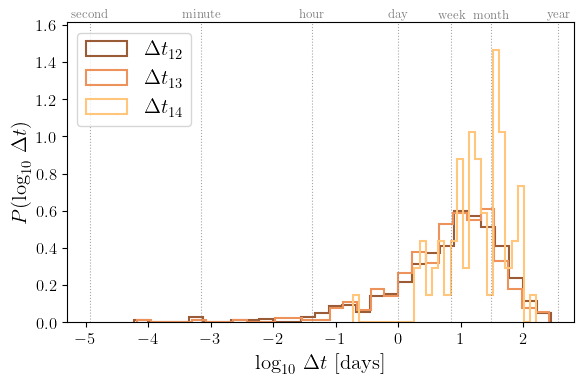

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

lensed_params_detectable = get_param_from_json("ler_data/n_lensed_params_bbh.txt")

dt_eff = lensed_params_detectable['time_delays']
dt12 = abs(dt_eff[:,1]-dt_eff[:,0])/ (24*3600)
dt13 = abs(dt_eff[:,2]-dt_eff[:,0])/ (24*3600)
dt14 = abs(dt_eff[:,3]-dt_eff[:,0])/ (24*3600)

snr_l = lensed_params_detectable['optimal_snr_net']
dt12 = dt12[snr_l[:,1]>10]
dt13 = dt13[snr_l[:,2]>10]
dt14 = dt14[snr_l[:,3]>10]

dt12 = dt12[~np.isnan(dt12)]
dt13 = dt13[~np.isnan(dt13)]
dt14 = dt14[~np.isnan(dt14)]

log_t12 = np.log10(dt12)
log_t13 = np.log10(dt13)
log_t14 = np.log10(dt14)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(log_t12, bins=30, density=True, histtype='step',
        color='#995C37', linewidth=1.5, label=r'$\Delta t_{12}$')
ax.hist(log_t13, bins=30, density=True, histtype='step',
        color='#ED925B', linewidth=1.5, label=r'$\Delta t_{13}$')
ax.hist(log_t14, bins=30, density=True, histtype='step',
        color='#FFC67C', linewidth=1.5, label=r'$\Delta t_{14}$')
# get y limits after plotting
ymax = ax.get_ylim()[1]

# reference lines
time_refs = {
    'second':  np.log10(1./(24*60*60)),
    'minute': np.log10(1./(24*60)),
    'hour':   np.log10(1./24),
    'day':    np.log10(1.),
    'week':   np.log10(7.),
    'month':  np.log10(30.),
    'year':   np.log10(365.),
}

ax.set_ylim(0, ymax * 1.25)

for label, xval in time_refs.items():
    ax.axvline(xval, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.text(xval, ymax * 1.095, label, ha='center', va='top',
            fontsize=9, color='grey')

ax.set_xlabel(r'$\log_{10}\,\Delta t$ [days]', fontsize=15)
ax.set_ylabel(r'$P(\log_{10}\,\Delta t)$', fontsize=15)
ax.legend(frameon=True, fontsize=15)
ax.tick_params(axis='both', which='major', direction='out',
               top=False, right=False)
ax.minorticks_off()
ax.set_ylim(0, ymax * 1.05)

fig.tight_layout()
fig.savefig('time_delays_ler.png', dpi=250)
plt.show()

In [8]:
# Extract the two biggest maximums of SNRs with 70% prob. for each detector

# Upload the json file
with open("ler_data/n_lensed_params_bbh.txt", "r") as file:
    data = json.load(file)

snr = data["optimal_snr_net"]

# Detection probability per image per detector
prob_det = 0.7
selected_events = [] #final list of two maximun snrs

for i, sublist in enumerate(snr):  # list of SNRs per image for event i
    n_images = len(sublist)
    if n_images < 2: # Skip events with fewer than 2 images
        continue

    detected_snrs = [] #list with sublists of detected images
    detected_indices = []  #list with indices of each image inside an event (used to keep only the same indices of other parameters)

    
    # Apply independent detection for each image and detector
    for j in range(n_images): # Random detection outcome for both detectors
        detected_L1 = np.random.rand() < prob_det #70% of the times = True
        detected_H1 = np.random.rand() < prob_det

         # Keep only if both detectors detect this image
        if detected_L1 and detected_H1 and not np.isnan(sublist[j]) and sublist[j] >= 10: #if value=Nan the image is not considered, SNR>=10
            detected_snrs.append(sublist[j])
            detected_indices.append(j)  #indices of each image

    if len(detected_snrs) < 2: # Discard event if fewer than 2 images are detected by both
        continue
    elif len(detected_snrs) > 2:
        # Keep only the two images with highest SNRs
        sorted_pairs = sorted(zip(detected_snrs, detected_indices), reverse=True) # Join both lists in pairs and sort descending according to the first element of the pair (snr)
        detected_snrs, detected_indices = zip(*sorted_pairs[:2])  #take top 2 and split again into lists of snrs and indices

    selected_events.append({
        "event_id": i,
        "snrs": list(detected_snrs),
        "image_indices": list(detected_indices) 
    })

with open("selected_events.txt", "w") as f:
    for event in selected_events: #example of event: {"event_id": 0, "snrs": [15.2, 10.4], "image_indices": [0, 1]}
        f.write(f"Event {event['event_id']}: {event['snrs']}\n")

print(f"Total detected events: {len(selected_events)}")


Total detected events: 157


In [9]:
filtered_data = {}

# Loop over each parameter in the original data dictionary
for key, values in data.items():
    filtered_values = []
    
    # Loop over each detected event only
    for event in selected_events:
        index_event = event["event_id"] # index of the detected event
        img_index = event["image_indices"] # indices of detected images for that event

        event_values = values[index_event] # extract parameter values for this event

        # Case 1: parameter is a list (each image has a value)
        if isinstance(event_values, list): 
            filtered_values.append([event_values[k] for k in img_index]) # Keep only values for the surviving images
        
        # Case 2: parameter is scalar (one value per event)
        else:
            filtered_values.append(event_values)
            
    # Save the filtered values for this parameter
    filtered_data[key] = filtered_values

# Write filtered data to a new JSON/txt file
with open("ler_data/n_lensed_params_bbh_filtered.txt", "w") as outfile:
    json.dump(filtered_data, outfile, indent=2) #indent=2 for better visual

print("Saved filtered file.")

Saved filtered file.


In [15]:
# Extract the two biggest maximums of SNRs with 70% prob. for each detector
# Upload the json file
with open("ler_data/n_lensed_params_bbh.txt", "r") as file:
    data = json.load(file)
snr = data["optimal_snr_net"]

# Detection probability per image per detector
prob_det = 0.7

selected_events = []       # final list of two maximum snrs
duty_cycle_events = []     # events with >=2 images surviving duty cycle only (no SNR cut)

for i, sublist in enumerate(snr):  # list of SNRs per image for event i
    n_images = len(sublist)
    if n_images < 2:  # Skip events with fewer than 2 images
        continue

    duty_survived = []   # images surviving duty cycle, regardless of SNR
    detected_snrs = []   # images surviving duty cycle AND snr >= 10
    detected_indices = []

    for j in range(n_images):
        detected_L1 = np.random.rand() < prob_det
        detected_H1 = np.random.rand() < prob_det
        if detected_L1 and detected_H1 and not np.isnan(sublist[j]):
            duty_survived.append(sublist[j])
            if sublist[j] >= 10:
                detected_snrs.append(sublist[j])
                detected_indices.append(j)

    # Count events with >=2 images surviving duty cycle (before SNR cut)
    if len(duty_survived) >= 2:
        duty_cycle_events.append(i)

    # Existing SNR>=10 selection
    if len(detected_snrs) < 2:
        continue
    elif len(detected_snrs) > 2:
        sorted_pairs = sorted(zip(detected_snrs, detected_indices), reverse=True)
        detected_snrs, detected_indices = zip(*sorted_pairs[:2])
    selected_events.append({
        "event_id": i,
        "snrs": list(detected_snrs),
        "image_indices": list(detected_indices)
    })

print(f"Events surviving duty cycle (>=2 images, no SNR cut): {len(duty_cycle_events)}")
print(f"Total detected events (duty cycle + SNR>=10): {len(selected_events)}")

Events surviving duty cycle (>=2 images, no SNR cut): 309
Total detected events (duty cycle + SNR>=10): 157
